In [13]:
from data.data_utils import *
from atl_utils import *
from copy import deepcopy
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

## Array preparation: Pro+Bn, Pro+Indan

In [2]:
X_desc = joblib.load("./joblib_files/X_desc.joblib")
X_id = joblib.load("./joblib_files/X_id.joblib")
y = joblib.load("./joblib_files/y.joblib")
desc_names = joblib.load("./joblib_files/desc_names.joblib")

# Ala Indan as target
X_desc_source1, X_desc_target1 = X_desc[:83, :], X_desc[83:, :]
X_id_source1, X_id_target1 = X_id[:83, :], X_id[83:, :]
y_source1 = y[:83]

In [3]:
ProIndan = sheets_to_list_of_dfs("data/reaction_data.xlsx", ["ProIndan"])[0].iloc[:, 1:].to_numpy()
X_id_ProIndan, yield_ProIndan = ProIndan[:, :-1], ProIndan[:, -1].flatten()
X_desc_ProIndan = id_array_to_desc_array(X_id_ProIndan, True)

y_source2 = deepcopy(yield_ProIndan)
y_source2[y_source2 < 32] = 0
y_source2[y_source2 >= 32] = 1

In [4]:
X_desc_source = np.vstack((X_desc_source1, X_desc_ProIndan))
X_id_source = np.vstack((X_id_source1, X_id_ProIndan))
y_source = np.concatenate((y_source1, y_source2))

In [5]:
yield_target1 = sheets_to_list_of_dfs("data/reaction_data.xlsx", ["Source"])[0].iloc[:, -1].to_numpy()[83:]
y_target1 = deepcopy(yield_target1)
y_target1[y_target1 < 13] = 0
y_target1[y_target1 >= 13] = 1

In [6]:
# Newly collected Ala Indan
AlaIndan = sheets_to_list_of_dfs("data/reaction_data.xlsx", ["AlaIndan_ATL"])[0].iloc[:, 1:].to_numpy()
X_id_target2, yield_target2 = AlaIndan[:, :-1], AlaIndan[:, -1].flatten()
X_desc_target2 = id_array_to_desc_array(X_id_target2, True)

y_target2 = deepcopy(yield_target2)
y_target2[y_target2 < 13] = 0
y_target2[y_target2 >= 13] = 1

In [7]:
X_desc_target = np.vstack((X_desc_target1, X_desc_target2))
X_id_target = np.vstack((X_id_target1, X_id_target2))
y_target = np.concatenate((y_target1, y_target2))
yield_target = np.concatenate((yield_target1, yield_target2))

In [8]:
print(X_desc_source.shape, X_id_source.shape, y_source.shape, X_desc_target.shape, X_id_target.shape, y_target.shape, yield_target.shape)

(101, 58) (101, 8) (101,) (98, 58) (98, 8) (98,) (98,)


## Retrospective ATL vs random and TL

In [9]:
source_models = []

for i in range(100) :
    rfc =  RandomForestClassifier(n_estimators=100, max_depth=1, random_state=42+i, n_jobs=-1)
    rfc.fit(X_desc_source, y_source)
    source_models.append(rfc)

### TL with no updates

In [10]:
# TL modeling
TL_proba = []
for model in source_models :
    TL_proba.append(model.predict_proba(X_desc_target)[:, 1].reshape(-1, 1))
avg_TL_proba = np.mean(np.hstack((TL_proba)), axis=1)

In [11]:
# At which place does TL with no updates place the two instances with greater than 30% yields?
index_ordered_by_yields = np.argsort(yield_target)[::-1]
index_ordered_by_TL_proba = np.argsort(avg_TL_proba)[::-1]
print(list(index_ordered_by_TL_proba).index(index_ordered_by_yields[0]))
print(list(index_ordered_by_TL_proba).index(index_ordered_by_yields[1]))

35
50


### Random selection

In [ ]:
from numpy.random import shuffle

random_best_rxns_placements = np.zeros((2, 50))

for i in range(50):
    x = deepcopy(yield_target)
    shuffle(x)
    random_best_rxns_placements[:, i] = [
        list(x).index(37) // 6 +1, list(x).index(32) //6 + 1
    ]

# Average iteration where random search finds the best and second best reactions:
print(np.mean(random_best_rxns_placements, axis=1))

[9.02 7.12]


### ATL

In [19]:
indices_sampled = []
for i in range(15): # Assuming that we sample 6 at a time
    if i == 0 :
        model_list_to_use = deepcopy(source_models)
    voted_indices = []
    for model in model_list_to_use :
        pred_proba = model.predict_proba(X_desc_target)[:, 1]
        ranked_inds = np.argsort(pred_proba)[::-1]
        ranked_remaining_inds = [x for x in ranked_inds if x not in indices_sampled]
        selected_inds = ranked_remaining_inds[:12]
        voted_indices.extend(selected_inds)
    votes = Counter(voted_indices)
    finally_selected_inds = list(dict(votes.most_common(6)).keys())
    indices_sampled.extend(finally_selected_inds)
    yields_sampled = yield_target[finally_selected_inds]
    if np.sum(yields_sampled > 30) > 0 :
        print(i+1, yields_sampled)

    # Updating the models
    new_target_models = []
    for j in range(100):
        rfc = RandomForestClassifier(n_estimators=15, max_depth=1, random_state=42+j, n_jobs=-1)
        rfc.fit(X_desc_target, y_target)
        new_target_models.append(rfc)

    model_list_to_use = combine_two_model_list_shuffled(model_list_to_use, new_target_models)

4 [37. 25. 10. 23. 17.  9.]
7 [ 7. 17.  3.  0. 32.  7.]


### EDBO

In [37]:
from edbo import BO

# Preparing target descriptor array into dataframe to pass to EDBO
X_desc_df = pd.DataFrame(X_desc_target, columns=desc_names)
exindex = pd.DataFrame(np.hstack((X_desc_target, yield_target.reshape(-1, 1))), columns=desc_names+["Yield"])

In [44]:
where_found = np.zeros((2, 50))
for i in range(50):
    bo = BO(
        domain=X_desc_df, 
        exindex=exindex, 
        batch_size=6
    )
    bo.simulate(iterations=9, seed=i)
    
    yield_results = list(bo.obj.results_input().iloc[:, -1].to_numpy())
    if 37 in yield_results :
        where_found[0, i] = yield_results.index(37)
    else :
        where_found[0, i] = -1
    
    if 32 in yield_results :
        where_found[1, i] = yield_results.index(32)
    else :
        where_found[1, i] = -1

In [47]:
# the 32% yielding reaction is either not found at all or part of the first selection
where_found[1]

array([-1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,  3., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1.,  1.,  3.,  4., -1., -1., -1., -1., -1., -1., -1., -1.,  3.,
       -1., -1., -1.,  3., -1., -1., -1., -1., -1., -1., -1.])

/var/folders/05/jxqj_ld96mx38n9knzsjp58c0000gn/T/ipykernel_47072/3981680873.py:13: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([round(x, 0) for x in np.arange(0, 12, 2)], fontsize=10, fontfamily="arial")
/var/folders/05/jxqj_ld96mx38n9knzsjp58c0000gn/T/ipykernel_47072/3981680873.py:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([round(x, 0) for x in np.arange(0, 13, 2)], fontsize=10, fontfamily="arial")


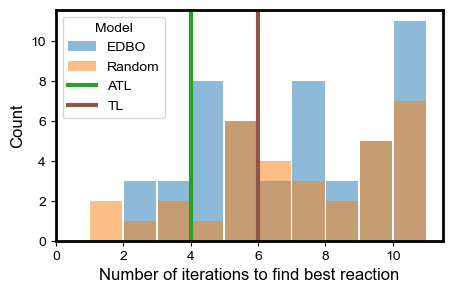

In [68]:
import matplotlib.font_manager as fm

iterations_found = [x // 6 +1 if x > 0 else 11 for x in where_found[0]]

fig, ax = plt.subplots(figsize=(5,3))
plt.hist(iterations_found, bins=np.arange(0, 12, 1), rwidth=0.95, alpha=0.5, label="EDBO")
plt.hist(random_best_rxns_placements[0], bins=np.arange(0, 12, 1), rwidth=0.95, color="#ff7f0e", alpha=0.5, label="Random")
ax.axvline(4, 0, 1, color="#2ca02c", label="ATL", lw=3)
ax.axvline(6, 0, 1, color="#8c564b", label="TL", lw=3)
ax.legend(title="Model", prop=fm.FontProperties(family="arial", size=10), title_fontproperties={"family":"arial", "size":10})
ax.set_xlabel("Number of iterations to find best reaction", fontsize=12, fontfamily="arial")
ax.set_xlim(0, 11.5)
ax.set_xticklabels([round(x, 0) for x in np.arange(0, 12, 2)], fontsize=10, fontfamily="arial")
ax.set_ylabel("Count", fontsize=12, fontfamily="arial")
ax.set_yticklabels([round(x, 0) for x in np.arange(0, 13, 2)], fontsize=10, fontfamily="arial")

for axis in ['top', 'bottom', 'left', 'right']:
    ax.spines[axis].set_linewidth(2)

plt.savefig("Retrospective_model_comparison_AlaIndan.svg", format="svg", dpi=300)